# Assistente RAG — Edificios Verdes & Net Zero (Agua e Energia)

**Global Solution — Processamento de Linguagem Natural, Chatbots & Virtual Agents**

| Etapa | Secao |
|-------|-------|
| Planejamento e escopo | 1 |
| Construcao do corpus | 2 |
| Limpeza e normalizacao | 3 |
| Segmentacao (chunking) | 4 |
| Embeddings e indexacao | 5 |
| Pipeline RAG com LLM local | 6 |
| Avaliacao | 7 |
| Visualizacao t-SNE e insumos do relatorio | 8 |

## 0. Instalacao de dependencias

Execute uma unica vez. Para o LLM local, instale o Ollama (https://ollama.com) e baixe o modelo:

```bash
ollama pull qwen2.5:3b
```

In [14]:
# !pip install -q -r ../requirements.txt

## 1. Planejamento e escopo

Edifícios verdes e Net Zero abrangendo energia e água, certificações, geração fotovoltaica, eficiência energética, automação predial, reuso e captação
de agua.

| Componente | Escolha | Justificativa                                                 |
|-----------|---------|---------------------------------------------------------------|
| Embedding | `intfloat/multilingual-e5-base` (768 dim) | Treinado para (query vs passagem), forte em português técnico. |
| Banco vetorial | ChromaDB persistente | Persistência simples em disco.                                |
| LLM | Ollama `qwen2.5:3b` | Modelo pequeno, bom desempenho em português.                  |

Prompt de sistema restringe a resposta aos trechos recuperados e
obriga citacao no formato `[fonte, ano]` em cada afirmacao tecnica.

In [15]:
import os, re, json, unicodedata
from collections import Counter

import numpy as np
import pandas as pd

DIRETORIO_BASE = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
DIRETORIO_CORPUS = os.path.join(DIRETORIO_BASE, 'corpus')
ARQUIVO_METADADOS = os.path.join(DIRETORIO_BASE, 'metadata.csv')
DIRETORIO_CHROMA = os.path.join(DIRETORIO_BASE, 'chroma_db')
DIRETORIO_SAIDAS = os.path.join(DIRETORIO_BASE, 'saidas')
os.makedirs(DIRETORIO_SAIDAS, exist_ok=True)

MODELO_EMBEDDING = 'intfloat/multilingual-e5-base'
MODELO_LLM = 'qwen2.5:3b'

TAMANHO_MINIMO_CHUNK = 256
TAMANHO_MAXIMO_CHUNK = 480
TAMANHO_OVERLAP_CHUNK = 80
TOP_K = 5

## 2. Construcao do corpus

Carrega o arquivo `metadata.csv` e valida que cada documento listado existe em `corpus/`. Os
metadados obrigatorios sao: fonte, categoria, subcategoria (energia ou agua), ano e vigencia.

In [16]:
metadados = pd.read_csv(ARQUIVO_METADADOS)
metadados['arquivo'] = metadados['arquivo'].str.strip()

total_documentos = len(metadados)
total_categorias = metadados['categoria'].nunique()
arquivos_ausentes = [
    nome for nome in metadados['arquivo']
    if not os.path.exists(os.path.join(DIRETORIO_CORPUS, nome))
]

print('=== Validacao do corpus ===')
print(f'Documentos listados em metadata.csv: {total_documentos}')
print(f'Categorias distintas: {total_categorias}')
print(f'Arquivos ausentes em corpus: {len(arquivos_ausentes)}')

if arquivos_ausentes:
    raise FileNotFoundError('Estes arquivos estao em metadata.csv mas faltam em corpus/:\n  - ' + '\n  - '.join(arquivos_ausentes))
if total_documentos < 10:
    raise ValueError(f'Corpus tem {total_documentos} documentos; minimo exigido pelo enunciado e 10.')
if total_categorias < 3:
    raise ValueError(f'Corpus tem {total_categorias} categorias; minimo exigido pelo enunciado e 3.')

print('\nValidacao OK.\n')
print('Distribuicao por categoria:')
print(metadados['categoria'].value_counts().to_string())
print('\nDistribuicao por subcategoria:')
print(metadados['subcategoria'].value_counts().to_string())

metadados

=== Validacao do corpus ===
Documentos listados em metadata.csv: 10
Categorias distintas: 3
Arquivos ausentes em corpus: 0

Validacao OK.

Distribuicao por categoria:
categoria
manual_tecnologia    4
certificacao         3
relatorio_tecnico    3

Distribuicao por subcategoria:
subcategoria
energia    6
agua       4


,arquivo,fonte,categoria,subcategoria,ano,vigencia
0,LEED v4 para Projeto e Construção de Edifícios...,USGBC,certificacao,energia,2014,vigente
1,Avaliação das Práticas Sustentáveis Aplicadas ...,AQUA-HQE/GBC Brasil,certificacao,agua,2020,vigente
2,LBC Living Building Challenge.pdf,Living Building Challenge,certificacao,agua,2021,vigente
3,IEA Joint Project Towards Net.pdf,IEA SHC Task 40,relatorio_tecnico,energia,2015,vigente
4,AUTOMAÇÃO PREDIAL TECNOLOGIA E GESTÃO EM PROL ...,ENCAC,relatorio_tecnico,energia,2019,vigente
5,REÚSO DE ÁGUAS CINZAS EM EDIFICAÇÕES URBANAS V...,periodico,relatorio_tecnico,agua,2020,vigente
6,Dimensionamento de Sistemas de Geração Fotovol...,fabricante,manual_tecnologia,energia,2020,vigente
7,Manual Geração Local de Energia Renovável e In...,orgao,manual_tecnologia,energia,2025,vigente
8,Aquecedor Solar.pdf,fabricante,manual_tecnologia,energia,2020,vigente
9,Aproveitamento de Água Pluvial.pdf,SABESP,manual_tecnologia,agua,2015,vigente


## 3. Limpeza e normalização

Remoção cabeçalhos, rodapés, encoding, tabelas extraídas formato markdown para manter fidelidade no chuncking.

In [17]:
from pypdf import PdfReader
import pdfplumber
import docx
from bs4 import BeautifulSoup

PDFPLUMBER_DISPONIVEL = True

# Unicode
def normalizar_encoding(texto: str) -> str:
    texto = unicodedata.normalize('NFKC', texto)
    texto = texto.replace('­', '')
    texto = re.sub(r'-\n(?=\w)', '', texto)
    texto = re.sub(r'[ \t]+', ' ', texto)
    texto = re.sub(r'\n{3,}', '\n\n', texto)
    return texto.strip()

# Conta linhas reptidas entre páginas
def remover_cabecalho_rodape(paginas):
    contador_linhas = Counter()
    linhas_por_pagina = []
    for pagina in paginas:
        linhas = [linha.strip() for linha in pagina.splitlines() if linha.strip()]
        linhas_por_pagina.append(linhas)
        for linha in set(linhas):
            contador_linhas[linha] += 1
    limite_repeticao = max(3, int(0.6 * len(paginas)))
    linhas_repetidas = {linha for linha, count in contador_linhas.items() if count >= limite_repeticao}
    paginas_limpas = []
    for linhas in linhas_por_pagina:
        mantidas = []
        for linha in linhas:
            if linha in linhas_repetidas:
                continue
            if re.fullmatch(r'(pag(\.|ina)?\s*)?\d{1,4}(\s*/\s*\d{1,4})?', linha, flags=re.I):
                continue
            mantidas.append(linha)
        paginas_limpas.append('\n'.join(mantidas))
    return '\n\n'.join(paginas_limpas)


# Criação da tabela no formato .md
def tabela_para_markdown(tabela):
    linhas = [[('' if celula is None else str(celula).strip()) for celula in linha] for linha in tabela if any(linha)]
    if not linhas:
        return ''
    cabecalho = linhas[0]
    saida = '| ' + ' | '.join(cabecalho) + ' |\n'
    saida += '| ' + ' | '.join('---' for _ in cabecalho) + ' |\n'
    for linha in linhas[1:]:
        linha = (linha + [''] * len(cabecalho))[:len(cabecalho)]
        saida += '| ' + ' | '.join(linha) + ' |\n'
    return saida


# Trata diferentes tipos de arquivos e extraí o conteúdo
def extrair_documento(caminho: str):
    extensao = os.path.splitext(caminho)[1].lower()
    tabelas_extraidas = []

    if extensao == '.pdf':
        if PDFPLUMBER_DISPONIVEL:
            paginas = []
            with pdfplumber.open(caminho) as pdf:
                for pagina in pdf.pages:
                    paginas.append(pagina.extract_text() or '')
                    for tabela in (pagina.extract_tables() or []):
                        tabela_md = tabela_para_markdown(tabela)
                        if tabela_md.count('\n') >= 3:
                            tabelas_extraidas.append(tabela_md)
        else:
            paginas = [pagina.extract_text() or '' for pagina in PdfReader(caminho).pages]
        texto = remover_cabecalho_rodape(paginas)
    elif extensao == '.docx':
        assert docx is not None, 'python-docx nao instalado'
        documento = docx.Document(caminho)
        texto = '\n'.join(p.text for p in documento.paragraphs)
        for tabela in documento.tables:
            tabelas_extraidas.append(tabela_para_markdown([[c.text for c in linha.cells] for linha in tabela.rows]))
    elif extensao in ('.html', '.htm'):
        with open(caminho, encoding='utf-8', errors='ignore') as arquivo:
            soup = BeautifulSoup(arquivo.read(), 'lxml')
        for tag in soup(['script', 'style', 'nav', 'footer', 'header']):
            tag.decompose()
        texto = soup.get_text('\n')
    else:
        with open(caminho, encoding='utf-8', errors='ignore') as arquivo:
            texto = arquivo.read()
    return normalizar_encoding(texto), tabelas_extraidas


documentos = {}

for _, linha in metadados.iterrows():
    caminho_arquivo = os.path.join(DIRETORIO_CORPUS, linha['arquivo'])
    texto_limpo, tabelas = extrair_documento(caminho_arquivo)
    documentos[linha['arquivo']] = {'texto': texto_limpo, 'tabelas': tabelas, 'meta': linha.to_dict()}
    print(f"{linha['arquivo']:<35} {len(texto_limpo):>7} chars | {len(tabelas)} tabela(s)")

LEED v4 para Projeto e Construção de Edifícios.pdf  355781 chars | 123 tabela(s)
Avaliação das Práticas Sustentáveis Aplicadas as Certificações Água-HQE e GBC Brasil Casa.pdf   35169 chars | 5 tabela(s)
LBC Living Building Challenge.pdf     16202 chars | 10 tabela(s)
IEA Joint Project Towards Net.pdf     30542 chars | 2 tabela(s)
AUTOMAÇÃO PREDIAL TECNOLOGIA E GESTÃO EM PROL DA.pdf   35952 chars | 4 tabela(s)
REÚSO DE ÁGUAS CINZAS EM EDIFICAÇÕES URBANAS VISANDO A.pdf   44172 chars | 5 tabela(s)
Dimensionamento de Sistemas de Geração Fotovoltaica.pdf   35145 chars | 0 tabela(s)
Manual Geração Local de Energia Renovável e Informativos.pdf   20983 chars | 1 tabela(s)
Aquecedor Solar.pdf                   26622 chars | 0 tabela(s)
Aproveitamento de Água Pluvial.pdf    35273 chars | 7 tabela(s)


## 4. Segmentacao - Chunking

- Divididos entre 256-480 tokens.

- Cada tabela vira um chunk próprio.

- Contador de tokens usa o tokenizer do modelo de embedding.

In [23]:
from transformers import AutoTokenizer

tokenizer =AutoTokenizer.from_pretrained('intfloat/multilingual-e5-base')

def n_tok(t):
    return len(tokenizer.encode(t, add_special_tokens=False))

def contar_tokens(texto: str) -> int:
    return len(tokenizer.encode(texto, add_special_tokens=False))

# Identificar títulos de seção
REGEX_SECAO = re.compile(
    r'^(?:'
    r'\d+(?:\.\d+)*\s+\S.*'
    r'|(?:cap[ií]tulo|se[cç][aã]o|artigo|art\.|cr[eé]dito|requisito|anexo)\s+[\dIVXLA-Z].*'
    r'|[A-Z][A-Z0-9 ,\-]{8,}'
    r')$', re.I | re.M)

# Divide o texto em seções
def dividir_em_secoes(texto: str):
    posicoes = [match.start() for match in REGEX_SECAO.finditer(texto)]
    if not posicoes:
        return [texto]
    posicoes = [0] + posicoes + [len(texto)]
    return [texto[posicoes[i]:posicoes[i+1]].strip() for i in range(len(posicoes)-1) if texto[posicoes[i]:posicoes[i+1]].strip()]

# Separação dos chuncks
def empacotar_paragrafos(secao: str):
    paragrafos = [p.strip() for p in re.split(r'\n\s*\n', secao) if p.strip()]
    chunks_resultantes, buffer, tokens_buffer = [], [], 0

    for paragrafo in paragrafos:
        tokens_paragrafo = contar_tokens(paragrafo)
        if tokens_paragrafo > TAMANHO_MAXIMO_CHUNK:

            sentencas = re.split(r'(?<=[.!?])\s+', paragrafo)
            sub_buffer, tokens_sub = [], 0

            for sentenca in sentencas:
                tokens_sentenca = contar_tokens(sentenca)
                if tokens_sub + tokens_sentenca > TAMANHO_MAXIMO_CHUNK and sub_buffer:
                    chunks_resultantes.append(' '.join(sub_buffer))
                    sub_buffer, tokens_sub = [], 0
                sub_buffer.append(sentenca)
                tokens_sub += tokens_sentenca

            if sub_buffer:
                chunks_resultantes.append(' '.join(sub_buffer))
            continue

        if tokens_buffer + tokens_paragrafo > TAMANHO_MAXIMO_CHUNK and buffer:
            chunks_resultantes.append('\n\n'.join(buffer))

            if contar_tokens(buffer[-1]) <= TAMANHO_OVERLAP_CHUNK:
                buffer, tokens_buffer = [buffer[-1]], contar_tokens(buffer[-1])
            else:
                buffer, tokens_buffer = [], 0

        buffer.append(paragrafo)
        tokens_buffer += tokens_paragrafo

    if buffer:
        chunks_resultantes.append('\n\n'.join(buffer))

    chunks_fundidos = []

    for chunk in chunks_resultantes:

        if chunks_fundidos and contar_tokens(chunks_fundidos[-1]) < TAMANHO_MINIMO_CHUNK and \
           contar_tokens(chunks_fundidos[-1]) + contar_tokens(chunk) <= TAMANHO_MAXIMO_CHUNK:
            chunks_fundidos[-1] = chunks_fundidos[-1] + '\n\n' + chunk
        else:
            chunks_fundidos.append(chunk)

    return chunks_fundidos


registros_chunks = []

for nome_arquivo, dados_documento in documentos.items():
    info_meta = dados_documento['meta']
    indice_chunk = 0
    for secao in dividir_em_secoes(dados_documento['texto']):
        for chunk in empacotar_paragrafos(secao):
            registros_chunks.append({'id': f"{nome_arquivo}#c{indice_chunk}", 'arquivo': nome_arquivo,
                                     'texto': chunk, 'tipo': 'texto',
                                     'n_tokens': contar_tokens(chunk), **info_meta})
            indice_chunk += 1
    for indice, tabela in enumerate(dados_documento['tabelas']):
        registros_chunks.append({'id': f"{nome_arquivo}#t{indice}", 'arquivo': nome_arquivo,
                                 'texto': tabela, 'tipo': 'tabela',
                                 'n_tokens': contar_tokens(tabela), **info_meta})

df_chunks = pd.DataFrame(registros_chunks)
print(f'Total de chunks: {len(df_chunks)}')

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (590 > 512). Running this sequence through the model will result in indexing errors


Total de chunks: 1460


Relatório de chunking
Total de chunks 1460
Tamanho médio (tokens) 143.6
Min / Max tokens 1 / 1827
Chunks-tabela 157

Distribuição por categoria:
                   chunks  tok_medio
categoria                           
certificacao          956      152.0
manual_tecnologia     254      131.7
relatorio_tecnico     250      123.7

Distribuição por subcategoria:
subcategoria
agua        220
energia    1240
Name: id, dtype: int64


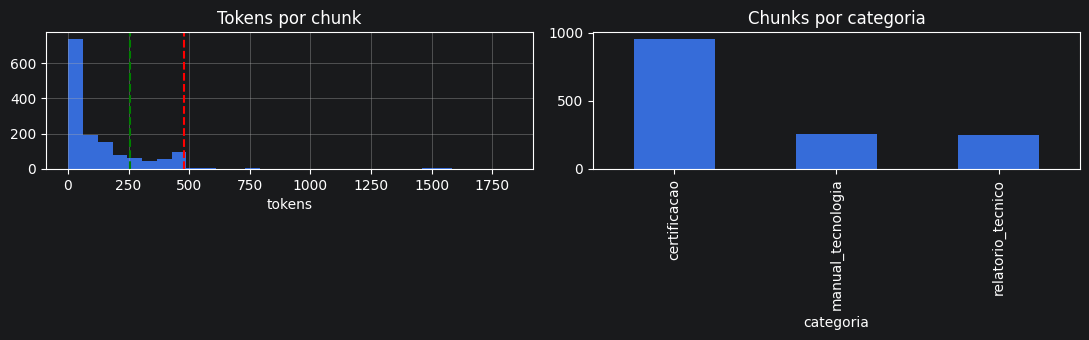

In [26]:
print('Relatório de chunking')
print(f"Total de chunks {len(df_chunks)}")
print(f"Tamanho médio (tokens) {df_chunks['n_tokens'].mean():.1f}")
print(f"Min / Max tokens {df_chunks['n_tokens'].min()} / {df_chunks['n_tokens'].max()}")
print(f"Chunks-tabela {(df_chunks['tipo']=='tabela').sum()}")
print('\nDistribuição por categoria:')
print(df_chunks.groupby('categoria').agg(chunks=('id','count'), tok_medio=('n_tokens','mean')).round(1))
print('\nDistribuição por subcategoria:')
print(df_chunks.groupby('subcategoria')['id'].count())

import matplotlib.pyplot as plt

figura, eixos = plt.subplots(1, 2, figsize=(11, 3.5))
df_chunks['n_tokens'].hist(bins=30, ax=eixos[0])
eixos[0].axvline(TAMANHO_MINIMO_CHUNK, color='g', ls='--')
eixos[0].axvline(TAMANHO_MAXIMO_CHUNK, color='r', ls='--')
eixos[0].set_title('Tokens por chunk'); eixos[0].set_xlabel('tokens')
df_chunks['categoria'].value_counts().plot.bar(ax=eixos[1])
eixos[1].set_title('Chunks por categoria')
plt.tight_layout()
plt.savefig(os.path.join(DIRETORIO_SAIDAS, 'relatorio_chunking.png'), dpi=120)
plt.show()

## 5. Geração de embeddings e indexação em ChromaDB

- Os embeddings são gerados por `multilingual-e5-base`.

- A indexacao usa ChromaDB com persistência em disco e armazena os metadados junto a cada
chunk, o que permite filtrar a busca por categoria ou subcategoria.

In [20]:
from sentence_transformers import SentenceTransformer
import chromadb

modelo_embedding = SentenceTransformer(MODELO_EMBEDDING)

# Passage é o prefixo obrigatório do modelo
def gerar_embedding_passagens(textos):
    return modelo_embedding.encode(['passage: ' + texto for texto in textos],
                                   normalize_embeddings=True,
                                   show_progress_bar=True,
                                   convert_to_numpy=True)

# Query prefixo obrigatório
def gerar_embedding_pergunta(pergunta):
    return modelo_embedding.encode(['query: ' + pergunta],
                                   normalize_embeddings=True,
                                   convert_to_numpy=True)[0]

# Banco Vetorial
cliente_chroma = chromadb.PersistentClient(path=DIRETORIO_CHROMA)

# "Sobrescrever" banco anterior
try:
    cliente_chroma.delete_collection('net_zero')
except Exception:
    pass

colecao = cliente_chroma.create_collection('net_zero', metadata={'hnsw:space': 'cosine'})

vetores = gerar_embedding_passagens(df_chunks['texto'].tolist())
metadados_chunks = df_chunks[['arquivo','fonte','categoria','subcategoria','ano','vigencia','tipo','n_tokens']].astype(str).to_dict('records')
colecao.add(ids=df_chunks['id'].tolist(),
            embeddings=vetores.tolist(),
            documents=df_chunks['texto'].tolist(),
            metadatas=metadados_chunks)

print(f'Indexados {colecao.count()} chunks em ChromaDB -> {DIRETORIO_CHROMA}')

Batches: 100%|██████████| 46/46 [02:23<00:00,  3.12s/it]


Indexados 1460 chunks em ChromaDB -> F:\FIAP\Segundo Ano\GS\Primeiro Semestre\Processamento de Linguagem Natural, Chatbots & Virtual Agents\global-solution-nlp-primeiro-semestre\chroma_db


## 6. Pipeline RAG com LLM local (Ollama)

- A funcao `recuperar` busca os top-k chunks mais similares e aceita filtro opcional por metadado.

- A funcao `responder` monta o contexto, aplica o prompt de sistema anti-alucinacao e chama o LLM
via Ollama exigindo citacao da fonte em cada afirmacao tecnica.

In [29]:
import ollama

PROMPT_SISTEMA = (
    "# Você é um assistente técnico especializado em edifícios verdes e Net Zero de energia e água. "
    "- Responda **exclusivamente** com base nos trechos fornecidos no contexto. "
    "- Se a informação não estiver no contexto, diga claramente: 'Não encontrei essa informação no corpus.'. "
    "- **NUNCA** invente dados, números ou normas. "
    "- Para cada afirmação técnica cite a fonte entre colchetes no formato [fonte, ano]. "
    "## Saída Obrigatória"
    "- Responda em português, de forma objetiva e técnica."
)


# Transformar pergunta em embeeding, busca vetores e retorna os chuncks
def recuperar(pergunta, k=TOP_K, filtro=None):
    vetor_pergunta = gerar_embedding_pergunta(pergunta)
    resultado_busca = colecao.query(query_embeddings=[vetor_pergunta.tolist()],
                                    n_results=k, where=filtro,
                                    include=['documents', 'metadatas', 'distances'])
    chunks_recuperados = []
    for documento, metadado, distancia in zip(resultado_busca['documents'][0],
                                              resultado_busca['metadatas'][0],
                                              resultado_busca['distances'][0]):
        chunks_recuperados.append({'texto': documento, 'meta': metadado, 'score': 1 - distancia})
    return chunks_recuperados

# Recupera os chuncks e monta o contexto
def montar_contexto(chunks_recuperados):
    blocos = []
    for indice, chunk in enumerate(chunks_recuperados, 1):
        info = chunk['meta']
        blocos.append(f"[Trecho {indice} | fonte: {info['fonte']}, {info['ano']} | arquivo: {info['arquivo']}]\n{chunk['texto']}")
    return '\n\n---\n\n'.join(blocos)

# Pergunta, busca, recupera, monta contexto, llm, retorna resposta
def responder(pergunta, k=TOP_K, filtro=None, modelo=MODELO_LLM):
    chunks_recuperados = recuperar(pergunta, k=k, filtro=filtro)
    contexto = montar_contexto(chunks_recuperados)

    mensagem_usuario = f"CONTEXTO:\n{contexto}\n\nPERGUNTA: {pergunta}\n\nResponda citando às fontes [fonte, ano]."

    resposta_llm = ollama.chat(model=modelo, messages=[
        {'role': 'system', 'content': PROMPT_SISTEMA},
        {'role': 'user', 'content': mensagem_usuario}
    ], options={'temperature': 0.1})

    texto_resposta = resposta_llm['message']['content']
    fontes_citadas = sorted({
        f"{m['fonte']} ({m['ano']}) - {m['arquivo']}"
        for c in chunks_recuperados
        for m in [c['meta']]
    })

    return {'pergunta': pergunta, 'resposta': texto_resposta,
            'fontes': fontes_citadas, 'hits': chunks_recuperados}

In [30]:
resultado = responder('Como funciona o reaproveitamento de águas cinzas em edifícios?')

print(resultado['resposta'])
print('\nFONTES:')

for fonte in resultado['fontes']:
    print(' -', fonte)

O reaproveitamento de águas cinzas em edifícios funciona através da utilização de tecnologias descentralizadas para o tratamento dessas águas. Essa abordagem permite a produção de água de reúso no próprio local onde as águas cinzas são geradas, permitindo seu uso para diversos fins como descarga em bacias sanitárias e mictórios, lavagem de pisos e veículos, contenção de incêndios e irrigação paisagística [VAN DEN WALLE et al., 2023]. 

A carga poluidora das águas cinzas é consideravelmente menor do que a das águas negras, o que pode minimizar os riscos associados à sua posterior utilização. No entanto, um adequado sistema de tratamento deve ser empregado para garantir que as águas cinzas não representem uma ameaça à saúde ou ao meio ambiente [VUPPALADADIYAM et al., 2019]. 

Para identificar os parâmetros críticos e subsidiar a seleção de tecnologias de tratamento compatíveis com o reúso, é necessário analisar a composição quantitativa e qualitativa das águas cinzas geradas em edifícios

In [32]:
print('Recuperação filtrada por subcategoria = água')

# Consulta o banco vetorial por essa query e retorna os 3 mais similiares
for chunk in recuperar('captacao de agua da chuva', k=3, filtro={'subcategoria': 'agua'}):
    print(f"score={chunk['score']:.3f}  {chunk['meta']['arquivo']}  ({chunk['meta']['categoria']})")

Recuperação filtrada por subcategoria = água
score=0.877  Aproveitamento de Água Pluvial.pdf  (manual_tecnologia)
score=0.874  Aproveitamento de Água Pluvial.pdf  (manual_tecnologia)
score=0.872  Aproveitamento de Água Pluvial.pdf  (manual_tecnologia)


## 7. Avaliação do sistema

- As dez perguntas de `perguntas_teste.json` são executadas pelo RAG e o resultado e salvo em
`saidas/
- Três dessas perguntas são também respondidas pelo LLM sem contexto RAG
para evidenciar diferenças em precisão, rastreabilidade e ocorrência de alucinação.

In [33]:
with open(os.path.join(DIRETORIO_BASE, 'perguntas_teste.json'), encoding='utf-8') as arquivo:
    banco_perguntas = json.load(arquivo)

linhas_avaliacao = ['# Avaliacao RAG — 10 perguntas\n']

registros_avaliacao = []

for pergunta in banco_perguntas['perguntas']:
    resultado = responder(pergunta['pergunta'])
    linhas_avaliacao.append(f"## {pergunta['id']} ({pergunta['subcategoria']}) — {pergunta['pergunta']}\n")
    linhas_avaliacao.append(resultado['resposta'] + '\n')
    linhas_avaliacao.append('**Fontes citadas:**')
    linhas_avaliacao += [f"- {fonte}" for fonte in resultado['fontes']]
    linhas_avaliacao.append('\n**Verificacao manual:** [ ] info confere com a fonte\n')
    registros_avaliacao.append({'id': pergunta['id'],
                                'sub': pergunta['subcategoria'],
                                'pergunta': pergunta['pergunta'],
                                'top_fonte': resultado['hits'][0]['meta']['arquivo'],
                                'score': round(resultado['hits'][0]['score'], 3)})

with open(os.path.join(DIRETORIO_SAIDAS, 'avaliacao_rag.md'), 'w', encoding='utf-8') as arquivo:
    arquivo.write('\n'.join(linhas_avaliacao))

print('Salvo: saidas/avaliacao_rag.md')
pd.DataFrame(registros_avaliacao)

Salvo: saidas/avaliacao_rag.md


,id,sub,pergunta,top_fonte,score
0,P01,energia,O que caracteriza um edificio Net Zero Energy ...,LBC Living Building Challenge.pdf,0.859
1,P02,energia,Quais requisitos de eficiencia energetica a ce...,LEED v4 para Projeto e Construção de Edifícios...,0.884
2,P03,energia,Como dimensionar um sistema fotovoltaico para ...,Dimensionamento de Sistemas de Geração Fotovol...,0.887
3,P04,energia,Qual o papel de um sistema BEMS na operacao ef...,LEED v4 para Projeto e Construção de Edifícios...,0.835
4,P05,energia,Quais parametros de desempenho termico a ABNT ...,LEED v4 para Projeto e Construção de Edifícios...,0.850
5,P06,agua,O que e um edificio Net Zero Water e quais est...,LBC Living Building Challenge.pdf,0.871
6,P07,agua,Como funciona um sistema de reaproveitamento d...,REÚSO DE ÁGUAS CINZAS EM EDIFICAÇÕES URBANAS V...,0.869
7,P08,agua,Quais sao os criterios para dimensionar um sis...,Aproveitamento de Água Pluvial.pdf,0.889
8,P09,agua,Que requisitos de gestao da agua a certificaca...,Avaliação das Práticas Sustentáveis Aplicadas ...,0.897
9,P10,agua,Qual a qualidade minima de agua exigida para r...,Aproveitamento de Água Pluvial.pdf,0.852


In [34]:
def responder_sem_rag(pergunta, modelo=MODELO_LLM):
    resposta_llm = ollama.chat(model=modelo, messages=[
        {'role': 'system', 'content': 'Você é um assistente técnico. Responda em português.'},
        {'role': 'user', 'content': pergunta}
    ], options={'temperature': 0.1})
    return resposta_llm['message']['content']

ids_para_comparar = banco_perguntas['metadata']['comparar_sem_rag']
linhas_comparacao = ['# Comparação RAG vs LLM puro\n']

for pergunta in [p for p in banco_perguntas['perguntas'] if p['id'] in ids_para_comparar]:
    resposta_com_rag = responder(pergunta['pergunta'], filtro={'subcategoria': pergunta['subcategoria']})
    resposta_sem_rag = responder_sem_rag(pergunta['pergunta'])

    linhas_comparacao += [
        f"## {pergunta['id']} — {pergunta['pergunta']}\n",
        '### Com RAG', resposta_com_rag['resposta'],
        '\n**Fontes:** ' + '; '.join(resposta_com_rag['fontes']),
        '\n### Sem RAG (LLM puro)', resposta_sem_rag,
        '\n**Análise:** precisao / rastreabilidade / alucinacao\n', '---\n'
    ]

with open(os.path.join(DIRETORIO_SAIDAS, 'comparacao_rag_vs_puro.md'), 'w', encoding='utf-8') as arquivo:
    arquivo.write('\n'.join(linhas_comparacao))

print('Salvo: saidas/comparacao_rag_vs_puro.md')

Salvo: saidas/comparacao_rag_vs_puro.md


## 8. Visualização t-SNE e insumos do relatório crítico


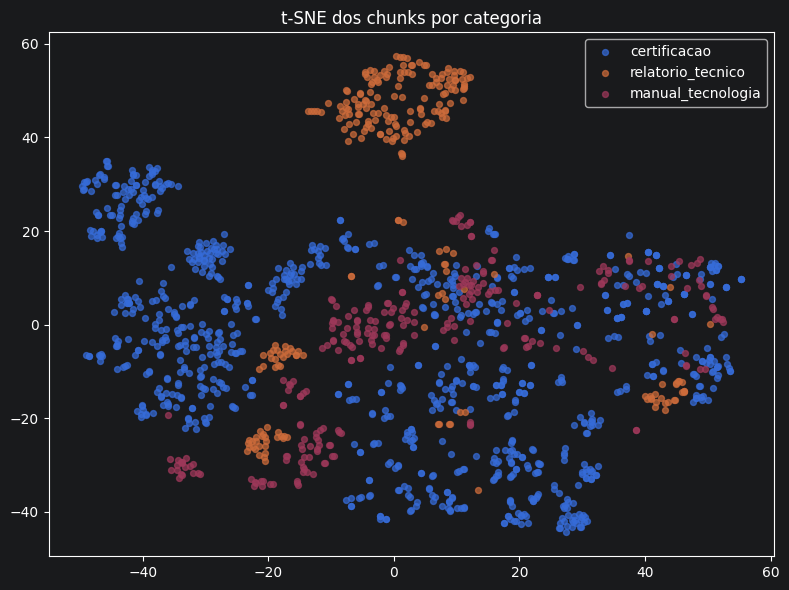

In [35]:
from sklearn.manifold import TSNE

perplexidade = max(5, min(30, len(vetores) // 3))
projecao_2d = TSNE(n_components=2, perplexity=perplexidade, init='pca', random_state=42).fit_transform(vetores)

plt.figure(figsize=(8, 6))

for categoria in df_chunks['categoria'].unique():
    mascara = (df_chunks['categoria'] == categoria).values
    plt.scatter(projecao_2d[mascara, 0], projecao_2d[mascara, 1], label=categoria, alpha=0.7, s=18)

plt.legend()
plt.title('t-SNE dos chunks por categoria')
plt.tight_layout()
plt.savefig(os.path.join(DIRETORIO_SAIDAS, 'tsne_categorias.png'), dpi=120)
plt.show()

In [36]:
print('Insumos do relatório crítico')
print(f"Documentos no corpus {len(metadados)}")
print(f"Categorias {dict(metadados['categoria'].value_counts())}")
print(f"Total de chunks {len(df_chunks)}")
print(f"Tokens/chunk (medio) {df_chunks['n_tokens'].mean():.1f}")
print(f"Perguntas avaliadas {len(banco_perguntas['perguntas'])}")
print(f"Perplexity t-SNE {perplexidade}")
print('\nScore medio do top-1 por pergunta:', round(np.mean([r['score'] for r in registros_avaliacao]), 3))
print('Perguntas com top-1 score < 0.80:')
for registro in registros_avaliacao:
    if registro['score'] < 0.80:
        print('  -', registro['id'], registro['pergunta'])

Insumos do relatório crítico
Documentos no corpus 10
Categorias {'manual_tecnologia': np.int64(4), 'certificacao': np.int64(3), 'relatorio_tecnico': np.int64(3)}
Total de chunks 1460
Tokens/chunk (medio) 143.6
Perguntas avaliadas 10
Perplexity t-SNE 30

Score medio do top-1 por pergunta: 0.869
Perguntas com top-1 score < 0.80:
